# Comparing Posteriors for Burst Model

## Imports

In [10]:
import h5py
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
def retrieve_data(z):

    folder = rf"D:\Users\nina\Star_Formation_Histories\fitting_delta\posteriors\burst\z_{z}"
    files = sorted(glob.glob(os.path.join(folder, "*.h5")))

    params = [ "age", "massformed", "metallicity", "Av", "logU"]    

    data_list = []

    for fpath in files:

        fname = os.path.basename(fpath)

        # Skip sampler files (those with "_")
        if "_" in fname:
            continue

        age_label = fname.replace(".h5", "")

        with h5py.File(fpath, "r") as f:
            median = f["median"][:]       # shape (6,)
            conf_int = f["conf_int"][:]   # shape (2,6)

        row = {
            "true_age": float(age_label)
        }

        for i, p in enumerate(params):
            row[f"{p}_median"] = median[i]
            row[f"{p}_lower"] = conf_int[0, i]
            row[f"{p}_upper"] = conf_int[1, i]

        data_list.append(row)

    df = pd.DataFrame(data_list)
    df = df.sort_values("true_age")

    return df

In [12]:
def plot_mass_recovery(df, true_mass=10.0):

    ages = df["true_age"]

    mass_median = df["massformed_median"]
    mass_lower = df["massformed_lower"]
    mass_upper = df["massformed_upper"]

    mass_frac_median = mass_median / true_mass
    mass_frac_lower = mass_lower / true_mass
    mass_frac_upper = mass_upper / true_mass

    err_lower = mass_frac_median - mass_frac_lower
    err_upper = mass_frac_upper - mass_frac_median

    plt.figure(figsize=(8,5))

    plt.errorbar(
        ages,
        mass_frac_median,
        yerr=[err_lower, err_upper],
        fmt="o",
        capsize=3,
        label="Recovered / True Mass",
        color="blue"
    )

    plt.axhline(1.0, linestyle="--", label="True Mass Fraction = 1", color="gray")

    plt.xlabel("Age [Gyr]")
    plt.ylabel("Recovered Mass Formed / True Mass")
    plt.title("Recovered Stellar Mass Fraction vs Age")

    plt.xscale("log")

    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [13]:
import matplotlib.pyplot as plt

def plot_age_recovery(df):

    ages = df["true_age"]

    age_median = df["age_median"]
    age_lower = df["age_lower"]
    age_upper = df["age_upper"]

    err_lower = age_median - age_lower
    err_upper = age_upper - age_median

    plt.figure(figsize=(8,5))

    plt.errorbar(
        ages,
        age_median,
        yerr=[err_lower, err_upper],
        fmt="o",
        capsize=3,
        label="Recovered Age",
        color="deeppink"
    )

    plt.plot(
        ages,
        ages,
        linestyle="--",
        color="gray",
        label="1:1 Line"
    )

    plt.xlabel("True Age [Gyr]")
    plt.ylabel("Recovered Age")
    plt.title("Recovered Stellar Age vs True Age")

    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [14]:
df_z2 = retrieve_data(2)
df_z3 = retrieve_data(3)
df_z4 = retrieve_data(4)

## Mass Comparison

### z = 2

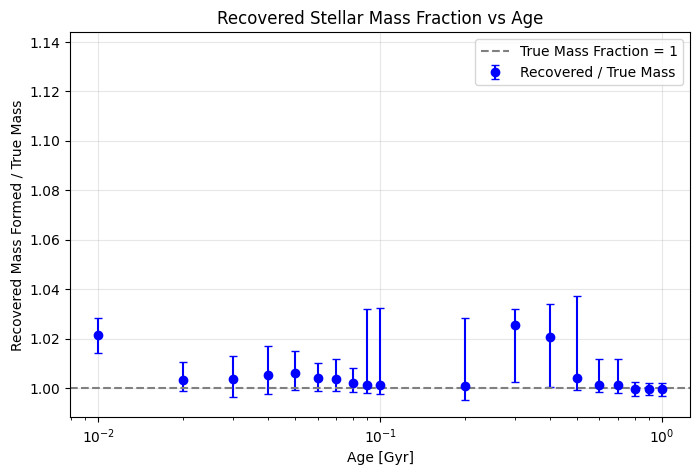

In [15]:
plot_mass_recovery(df_z2)

### z = 3

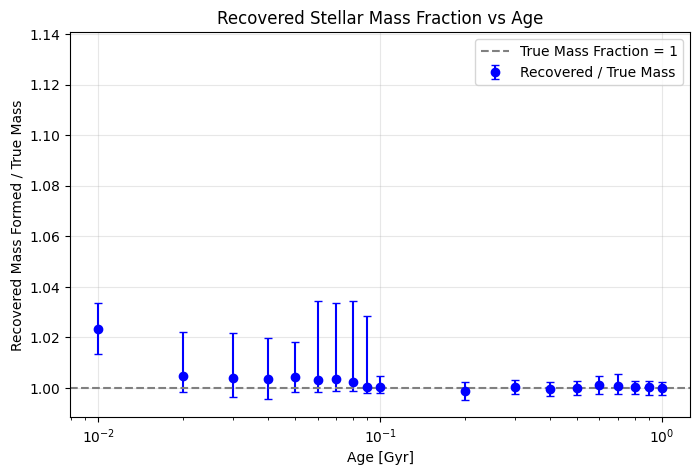

In [16]:
plot_mass_recovery(df_z3)

### z = 4

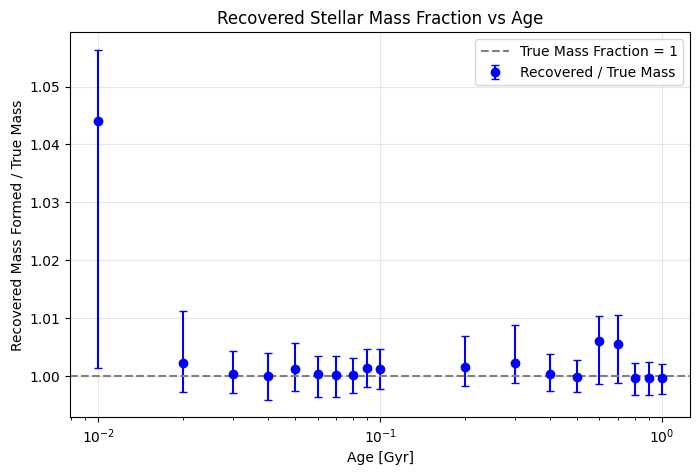

In [17]:
plot_mass_recovery(df_z4)

### z = 5

### z = 6

### z = 7

### z = 8

## Age Comparison

### z = 2

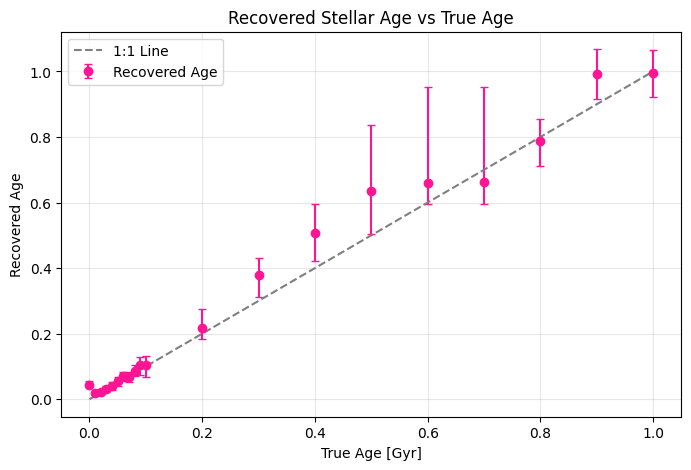

In [18]:
plot_age_recovery(df_z2)

### z = 3

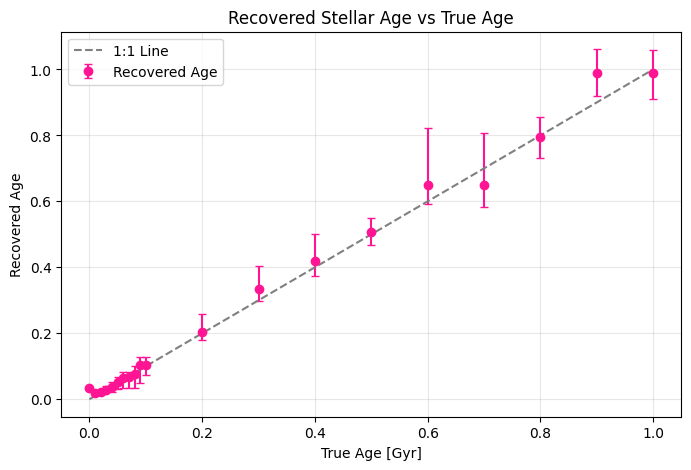

In [19]:
plot_age_recovery(df_z3)

### z = 4

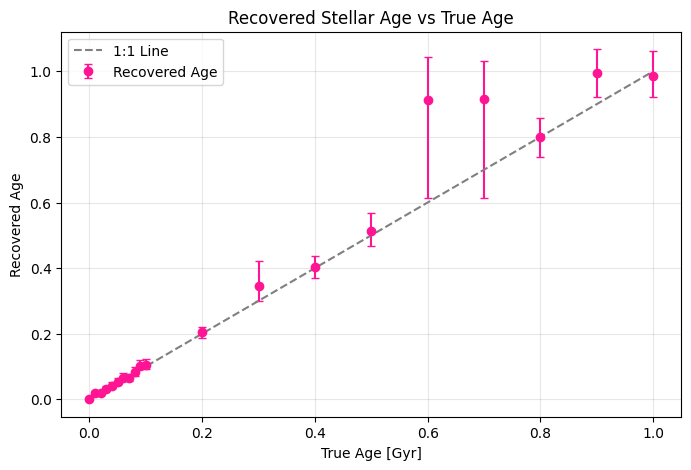

In [20]:
plot_age_recovery(df_z4)

### z = 5

### z = 6

### z = 7

### z = 8